# GLORYS12V1 SST Snapshot

Render a single PNG snapshot of sea surface temperature for the North Pacific.

In [4]:
import sys
sys.path.insert(0, '..')

from ocean_viz import load_ocean_data, render_snapshot

# Path to config file
config_path = '../configs/glorys12_sst_demo.yaml'

## Step 1: Load the configuration and data

In [5]:
# Load dataset from configuration
ds = load_ocean_data(config_path)

print(f"Dataset shape: {ds.sizes}")
print(f"Variables: {list(ds.data_vars)}")
print(f"Coordinates: {list(ds.coords)}")
print(f"\nDataset:\n{ds}")

Dataset shape: Frozen({'lat': 337, 'time': 9, 'lon': 240})
Variables: ['sst']
Coordinates: ['lat', 'depth', 'time', 'lon']

Dataset:
<xarray.Dataset> Size: 6MB
Dimensions:  (lat: 337, time: 9, lon: 240)
Coordinates:
  * lat      (lat) float32 1kB 40.0 40.08 40.17 40.25 ... 67.75 67.83 67.92 68.0
  * time     (time) datetime64[ns] 72B 2018-06-01T12:00:00 ... 2018-06-09T12:...
  * lon      (lon) float32 960B 160.0 160.1 160.2 160.2 ... 179.8 179.8 179.9
    depth    float32 4B 0.494
Data variables:
    sst      (time, lat, lon) float64 6MB dask.array<chunksize=(1, 265, 240), meta=np.ndarray>


## Step 2: Render snapshot

In [6]:
# Render PNG snapshot for first available date
png_path = render_snapshot(config_path)
print(f"Snapshot saved to: {png_path}")

Snapshot saved to: outputs/glorys12v1_sst_20180601_north_pacific_snapshot.png


## Step 3: Display the result

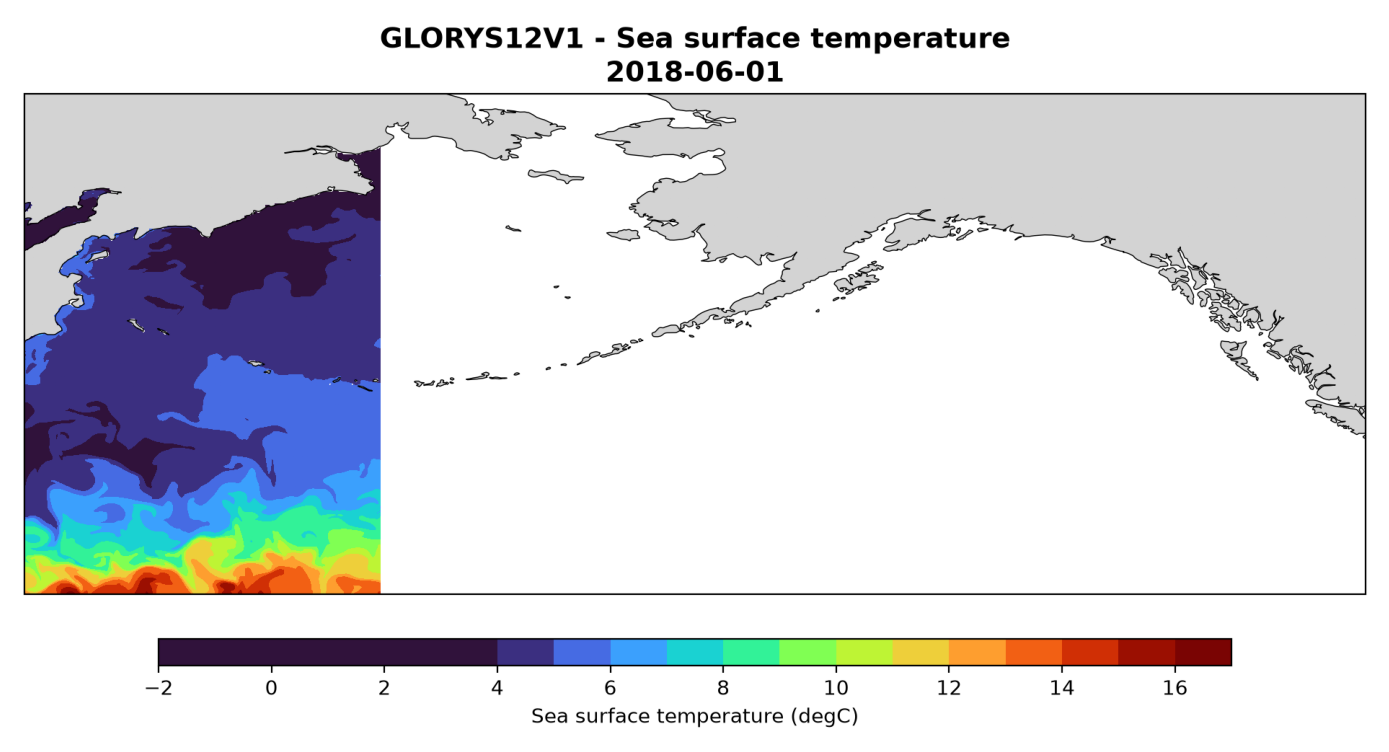

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(png_path)
plt.figure(figsize=(14, 10))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

## Step 4: Explore the data

Plot the raw data to verify it loaded correctly.

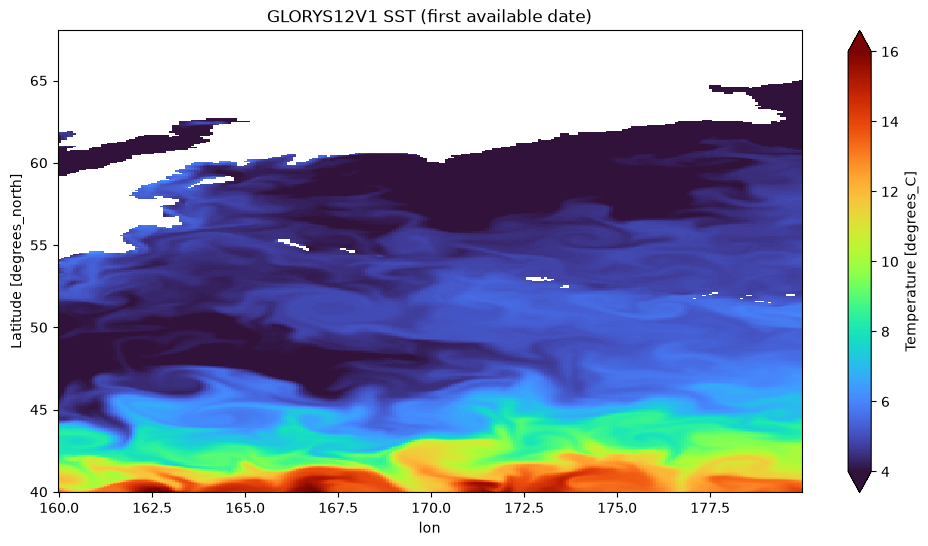

SST min: -1.28°C
SST max: 16.46°C
SST mean: 5.81°C


In [8]:
import matplotlib.pyplot as plt

# Select first timestep
sst = ds['sst'].isel(time=0)

fig, ax = plt.subplots(figsize=(12, 6))
sst.plot(ax=ax, cmap='turbo', vmin=4, vmax=16)
ax.set_title('GLORYS12V1 SST (first available date)')
plt.show()

print(f"SST min: {float(sst.min()):.2f}°C")
print(f"SST max: {float(sst.max()):.2f}°C")
print(f"SST mean: {float(sst.mean()):.2f}°C")